## Arquitectura del Sistema de Agentes

| Componente              | Rol en el Sistema              | Interacción Crítica |
|------------------------|------------------------------|--------------------|
| **Prompting** | Cerebro (*Razonamiento*)      | Define la identidad y el "espacio de solución" del agente. Es la interfaz entre el código y la semántica. |
| **Herramientas** | Extremidades (*Acción*)     | Permite que el razonamiento del componente Prompting se convierta en acciones reales (consultar APIs, bases de datos). |
| **Memoria**   | Hipocampo (*Contexto*)        | Provee persistencia. El razonamiento del componente Prompting se ajusta según lo aprendido en el pasado. |
| **Planeación**| Lóbulo Frontal (*Estrategia*) | Antes de actuar, el sistema descompone la meta. Modula cómo se usan las herramientas. |
| **Orquestación** | Sistema Nervioso (*Grafo*) | El "pegamento" técnico. Define quién habla con quién y cuándo termina una tarea. |

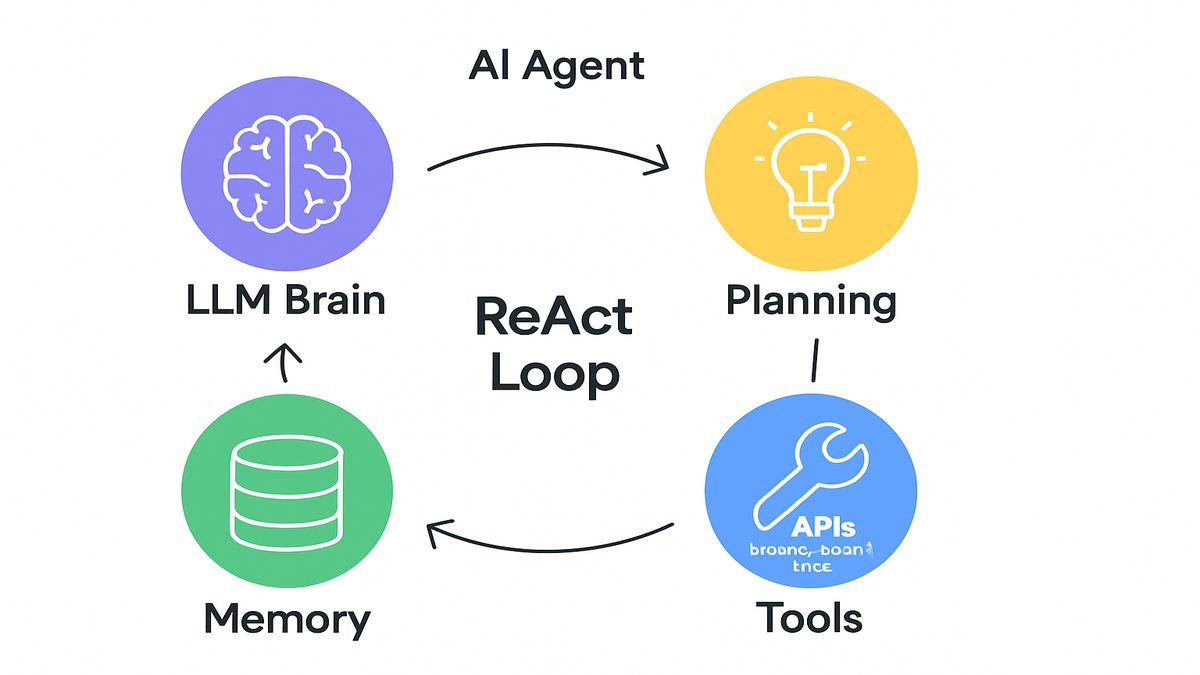

In [9]:
# Instala las bibliotecas necesarias para LangChain y LangSmith.
# - `langchain`: El framework principal para construir aplicaciones con LLMs.
# - `langchain-openai`: Integración con modelos de OpenAI (aunque aquí se usa un LLM compatible con OpenAI API).
# - `langsmith`: Herramienta para observar, monitorear y evaluar el ciclo de vida de las aplicaciones basadas en LLMs.
# - `langchain-community`: Componentes adicionales de la comunidad de LangChain.
!pip install -q langchain langchain-openai langsmith langchain-community

In [12]:
import os
from google.colab import userdata
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from google.colab.userdata import SecretNotFoundError

# Inicializa variables para la URL base y la clave de API del LLM.
# Por defecto, se establece la URL base de OpenAI.
llm_base_url = "https://api.openai.com/v1" # URL base por defecto para OpenAI
llm_api_key = None # Se inicializa como None, se asignará en el bloque try-except

# Intenta obtener los secretos para un LLM compatible con OpenAI API alojado en GitHub.
# Si estos secretos existen, sobrescribirán los valores por defecto.
try:
    github_base_url = userdata.get('GITHUB_BASE_URL')
    github_token = userdata.get('GITHUB_TOKEN')
    llm_base_url = github_base_url
    llm_api_key = github_token
    print("Usando GITHUB_BASE_URL y GITHUB_TOKEN de los secretos de Colab.")
except SecretNotFoundError:
    print("Los secretos 'GITHUB_BASE_URL' o 'GITHUB_TOKEN' no se encontraron.")
    # Si los secretos de GitHub no están, intenta usar la clave de API de OpenAI estándar.
    try:
        llm_api_key = userdata.get('OPENAI_API_KEY')
        print("Usando OPENAI_API_KEY de los secretos de Colab.")
    except SecretNotFoundError:
        print("El secreto 'OPENAI_API_KEY' tampoco se encontró en Colab.")
        # Fallback a variables de entorno si no se encuentra en userdata.
        if "OPENAI_API_KEY" in os.environ:
            llm_api_key = os.environ["OPENAI_API_KEY"]
            print("Usando OPENAI_API_KEY de las variables de entorno.")
        else:
            print("ERROR: No se encontró ninguna clave de API (GITHUB_TOKEN ni OPENAI_API_KEY) en los secretos de Colab ni en las variables de entorno.")
            print("Por favor, configura tu 'OPENAI_API_KEY' como un secreto de Colab para que el código funcione.")
            # Asigna un valor dummy para evitar NameError, pero la invocación real del LLM fallará sin una clave válida.
            llm_api_key = "sk-dummykey"

# Inicializa el modelo de lenguaje (LLM).
# - `base_url`: La URL base del API del LLM.
# - `api_key`: La clave de API para autenticación.
# - `model`: Especifica el modelo a utilizar (por ejemplo, 'gpt-4o').
# - `temperature`: Controla la creatividad de la salida. 0.0 significa que la salida será más determinista.
llm = ChatOpenAI(
    base_url=llm_base_url,
    api_key=llm_api_key,
    model="gpt-4o",
    temperature=0.0
)

# Define el mensaje del sistema para el prompt.
# Esto establece el rol y el propósito del LLM en la conversación.
system_template = "Eres un Arquitecto de Soluciones experto en IA. Tu objetivo es desglosar problemas complejos"

# Crea una plantilla de prompt para el chat.
# Utiliza un mensaje del sistema fijo y un mensaje del usuario que será dinámico (problema).
prompt_template = ChatPromptTemplate.from_messages(
    [
        ("system", system_template),
        ("user", "{problema}")
    ]
)

# Crea una cadena de ejecución: el prompt se pasa al LLM.
chain = prompt_template | llm

# Invoca la cadena con un problema específico y obtiene la respuesta del LLM.
respuesta = chain.invoke({"problema": "¿Cual es la diferencia tecnica entre un LLM y un Agente Inteligente?"})

# Imprime el contenido de la respuesta generada por el LLM.
print(respuesta.content)

NameError: name 'GOOGLE_API_KEY' is not defined

In [ ]:
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, ToolMessage


# Define una herramienta personalizada usando el decorador `@tool`.
# Esta función `multiplicar_numeros` toma dos números flotantes y devuelve su producto.
# La cadena de documentación (`"Multiplica dos numeros..."`) es la descripción que el LLM usará para decidir cuándo usar esta herramienta.
@tool
def multiplicar_numeros(a: float, b: float) -> float:
    "Multiplica dos numeros decimales o enteros. Usalo para cálculos matemáticos precisos."
    return a * b


# Crea una lista de herramientas disponibles para el LLM.
tools = [multiplicar_numeros]

# "Bind" las herramientas al LLM. Esto le permite al LLM saber que puede usar estas herramientas.
# Cuando el LLM detecta que necesita una herramienta, generará un `tool_call`.
llm_with_tools = llm.bind_tools(tools)

# Define la consulta del usuario que requiere una herramienta.
query = "¿Cuánto es 155.5 multiplicado por 12.3?"

# Inicia una lista de mensajes con la consulta del usuario.
messages = [HumanMessage(content=query)]

# Invoca el LLM con las herramientas. El LLM debería identificar que necesita la herramienta `multiplicar_numeros`.
respuesta_ai = llm_with_tools.invoke(messages)

# Agrega la respuesta del LLM (que contiene el `tool_call`) a la conversación.
messages.append(respuesta_ai)


# Itera sobre los `tool_calls` que el LLM ha decidido hacer.
for tool_call in respuesta_ai.tool_calls:
    # Selecciona la función de herramienta correcta basándose en el nombre del `tool_call`.
    selected_tool = {"multiplicar_numeros": multiplicar_numeros}[tool_call["name"].lower()]
    # Ejecuta la herramienta con los argumentos proporcionados por el LLM.
    tool_output = selected_tool.invoke(tool_call["args"])
    # Agrega el resultado de la herramienta a los mensajes para que el LLM pueda usarlo.
    messages.append(ToolMessage(tool_output, tool_call_id=tool_call["id"]))


# Invoca el LLM de nuevo con el resultado de la herramienta. Ahora el LLM puede formular una respuesta final basándose en el cálculo.
respuesta_final = llm_with_tools.invoke(messages)

# Imprime la respuesta final del LLM.
print(respuesta_final.content)

In [ ]:
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory

# Inicializa un historial de mensajes para almacenar la conversación.
# `ChatMessageHistory` guarda los mensajes en memoria para una sesión específica.
memoria_historial = ChatMessageHistory()

# Define una plantilla de prompt con un mensaje de sistema, un placeholder para el historial
# y un mensaje humano para la entrada actual.
# El `{history}` será reemplazado por los mensajes anteriores de la conversación.
prompt_con_memoria = ChatPromptTemplate.from_messages([
    ("system", "Eres un asistente con memoria persistente. Utiliza el historial para dar contexto atus respuestas."),
    ("placeholder", "{history}"),
    ("human", "{input}")
])

# Crea una cadena base que combina el prompt con el LLM.
chain_base = prompt_con_memoria | llm

# Envuelve la cadena base con `RunnableWithMessageHistory` para añadir gestión de historial.
# - El primer argumento es la cadena a la que se le añade la memoria.
# - El segundo argumento es una función que, dado un `session_id`, devuelve una instancia de `BaseChatMessageHistory`.
# - `input_messages_key`: Especifica la clave en la entrada del `invoke` que contiene el mensaje actual del usuario.
# - `history_messages_key`: Especifica la clave en el prompt que se reemplazará con el historial de mensajes.
agente_con_memoria = RunnableWithMessageHistory(
    chain_base,
    lambda session_id: memoria_historial,
    input_messages_key="input",
    history_messages_key="history"
)

# Define una configuración para la sesión, incluyendo un ID de sesión.
# Este `session_id` se usa para recuperar el historial de mensajes correcto.
configuracion = {"configurable": {"session_id": "usario_delta_1"}}

# Primera interacción: el agente responde y guarda el mensaje en el historial.
primera_respuesta = agente_con_memoria.invoke(
    {"input": "Hola, mi nombre R-22 y soy Investigador"},
    config=configuracion
)

print(f"Respuesta 1: {primera_respuesta.content}")

# Segunda interacción: el agente debería recordar el nombre y la profesión de la conversación anterior.
segunda_respuesta = agente_con_memoria.invoke(
    {"input": "Puedes recordar mi nombre y mi profesion?"},
    config=configuracion
)

print(f"Respuesta 2: {segunda_respuesta.content}")

In [ ]:
from pydantic import BaseModel, Field
from typing import List
from langchain_core.output_parsers import JsonOutputParser

# Define un modelo Pydantic para la estructura de la salida esperada.
# En este caso, un plan debe ser una lista de pasos (cadenas de texto).
class Plan(BaseModel):
  pasos: List[str] = Field(description="Lista secuencial de pasos para resolver el problema")

# Inicializa un `JsonOutputParser` que usará el modelo `Plan` para parsear la salida del LLM.
# Esto asegura que la salida del LLM tenga el formato JSON correcto y valida su estructura.
parser_planificador = JsonOutputParser(pydantic_object=Plan)

# Crea una plantilla de prompt específica para el agente planificador.
# - El mensaje del sistema instruye al LLM a generar un JSON siguiendo un formato específico.
# - `format_instructions` será completado por el parser para guiar al LLM sobre el JSON esperado.
# - El mensaje humano proporciona el requerimiento complejo a planificar.
prompt_planificador = ChatPromptTemplate.from_messages([
    ("system", "Eres un Agente Planificador. Tu salida debe ser exclusivamente un JSON que cumlpa con este formato: {format_instructions}"),
    ("human", "Diseña un plan para resolver este requerimiento: {requerimiento}")
])

# Construye la cadena de planificación: prompt -> LLM -> parser.
# El LLM genera texto que luego es parseado en un objeto Python (una instancia de `Plan`).
cadena_planificacion = prompt_planificador | llm | parser_planificador

# Define una tarea compleja que requiere planificación.
tarea_compleja = "Analizar el impacto financiero de una inflacion del 5% en una inversion de 10,000 USD a 3 años"

# Invoca la cadena de planificación con la tarea y las instrucciones de formato.
# `get_format_instructions()` del parser proporciona la guía de formato al LLM.
plan_generado = cadena_planificacion.invoke({
    "requerimiento": tarea_compleja,
    "format_instructions": parser_planificador.get_format_instructions()
})

print(" --- PLAN ESTRATEGICO GENERADO ---")

# Imprime cada paso del plan generado.
for i, paso in enumerate(plan_generado['pasos'], 1):
    print(f"Paso {i}: {paso}")

In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, END

# Define el estado compartido para los agentes en el workflow.
# `TypedDict` se usa para definir un diccionario con tipos de datos específicos.
# `mensaje`: la entrada o salida principal entre agentes.
# `historial_pasos`: una lista para registrar los pasos ejecutados por los agentes.
class EstadoAgente(TypedDict):
  mensaje: str
  historial_pasos: List[str]

# Define el primer agente: `agente_investigador`.
# Recibe el estado actual, realiza una "investigación" y actualiza el `historial_pasos`.
def agente_investigador(state: EstadoAgente):
    print(" ---Agente Investigador Activo---")

    input_usario = state["mensaje"]
    # Simula una operación de investigación y guarda un hallazgo.
    hallazgo = f"Investigacion sobre: {input_usario}. Resultado: Se detectaron 3 tendencias clave."
    # Retorna un nuevo estado, añadiendo el hallazgo al historial.
    return {"historial_pasos": state["historial_pasos"] + [hallazgo]}

# Define el segundo agente: `agente_redactor`.
# Recibe el estado actual, toma el último hallazgo del investigador y genera un "resumen".
def agente_redactor(state: EstadoAgente):
    print(" --- Agente Redactor Activo ---")
    # Obtiene el último elemento del historial de pasos.
    ultimo_hallazgo = state["historial_pasos"][-1]
    # Simula la redacción de un resumen basado en el hallazgo.
    resumen = f"Resumen ejecutivo basado en:  {ultimo_hallazgo}"

    # Retorna un nuevo estado, actualizando el `mensaje` con el resumen generado.
    return {"mensaje": resumen}

# Inicializa un `StateGraph` con el tipo de estado definido.
workflow = StateGraph(EstadoAgente)
# Agrega los nodos (agentes) al grafo, asociándolos con sus funciones.
workflow.add_node("investigador", agente_investigador)
workflow.add_node("redactor", agente_redactor)

# Establece el punto de entrada del workflow (dónde comienza la ejecución).
workflow.set_entry_point("investigador")
# Define las transiciones (bordes) entre los nodos.
# El investigador pasa su resultado al redactor.
workflow.add_edge("investigador", "redactor")
# El redactor es el último paso, por lo que su salida finaliza el workflow.
workflow.add_edge("redactor", END)

# Compila el workflow en una aplicación ejecutable.
aplicacion_agente = workflow.compile()

# Invoca la aplicación con un mensaje inicial y un historial de pasos vacío.
# El mensaje inicial será procesado por el `agente_investigador`.
resultado_final = aplicacion_agente.invoke({
    "mensaje": "El futuro de la computacion cuantica",
    "historial_pasos": []
})

# Imprime el mensaje final resultante del workflow.
print(f"Salida del Sistema: {resultado_final['mensaje']} ")